In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' ## Keep the critical logs
import time

import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import layers, models, callbacks, Input


# GPU availibility
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"Using Device: GPU ({len(gpus)} available)")
    # Optional: Display the specific name of the GPU
    for gpu in gpus:
        print(f"  - {gpu.name}")
else:
    print("Using Device: CPU")

E0000 00:00:1776167550.961188      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776167551.020592      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776167551.492774      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776167551.492810      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776167551.492813      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776167551.492816      55 computation_placer.cc:177] computation placer already registered. Please check linka

Using Device: GPU (2 available)
  - /physical_device:GPU:0
  - /physical_device:GPU:1


### Dataset Pipeline

In [2]:
# Set up the dataset paths and labels
data_path = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training'
classes = sorted(os.listdir(data_path))
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
# Build the list of file paths and labels
file_paths = []
labels = []

for cls_name in classes:
    cls_path = os.path.join(data_path, cls_name)
    for img_name in os.listdir(cls_path):
        file_paths.append(os.path.join(cls_path, img_name))
        labels.append(class_to_idx[cls_name])

# Basic preprocessing (except augmentations)
def process_path(file_path, label):
    """
    Read the image from the path as uint8 tensor and resize it to 224, 224 and cast it to float32
    """
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)   # Decode jpeg/png to a uint8 tensor
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 255.0     # Normalize to [0, 1] (equivalent to transforms.ToTensor)
    return img, label

## Define the dataset
dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))

## Split dataset into training and val as 80% for train and 20% for val
total_samples = len(file_paths)
train_size = int(0.8 * total_samples) 
val_size = total_samples - train_size
full_dataset = dataset.shuffle(total_samples, reshuffle_each_iteration=False) # Shuffle and split

train_ds = full_dataset.take(train_size)
val_ds = full_dataset.skip(train_size)

I0000 00:00:1776167577.472669      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776167577.478734      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


### Augmentation

Creating an augment function separately since we want validation data to be free of augmentations. This is a basic way to do this, better approaches exist!

In [3]:
## Here we create an augment function and add augmentations to the training dataset
## Both training and val datasets are converted to batches
def augment(img, label):
    """
    Basic tensorflow augmentations on images
    """
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    return img, label

# We create two config functions, one for train and one for val. This makes sure augmentation is only in train
def configure_train(ds):
    """
    Add augmentations and convert the dataset to batches of 32 - specifically for training dataset
    """
    return (
        ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
        .map(augment, num_parallel_calls=tf.data.AUTOTUNE) # Add this
        .batch(64)
        .prefetch(tf.data.AUTOTUNE)
    )

def configure_val(ds):
    """
    Convert the dataset to batches of 32 - specifically for val dataset
    """
    return (
        ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(64)
        .prefetch(tf.data.AUTOTUNE)
    )

# Apply to datasets
train_ds = configure_train(train_ds)
val_ds = configure_val(val_ds)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.032621503..1.0454569].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06991136..0.96023107].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0510483..1.0465294].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.031742573..1.0461401].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.10885444..0.93266344].


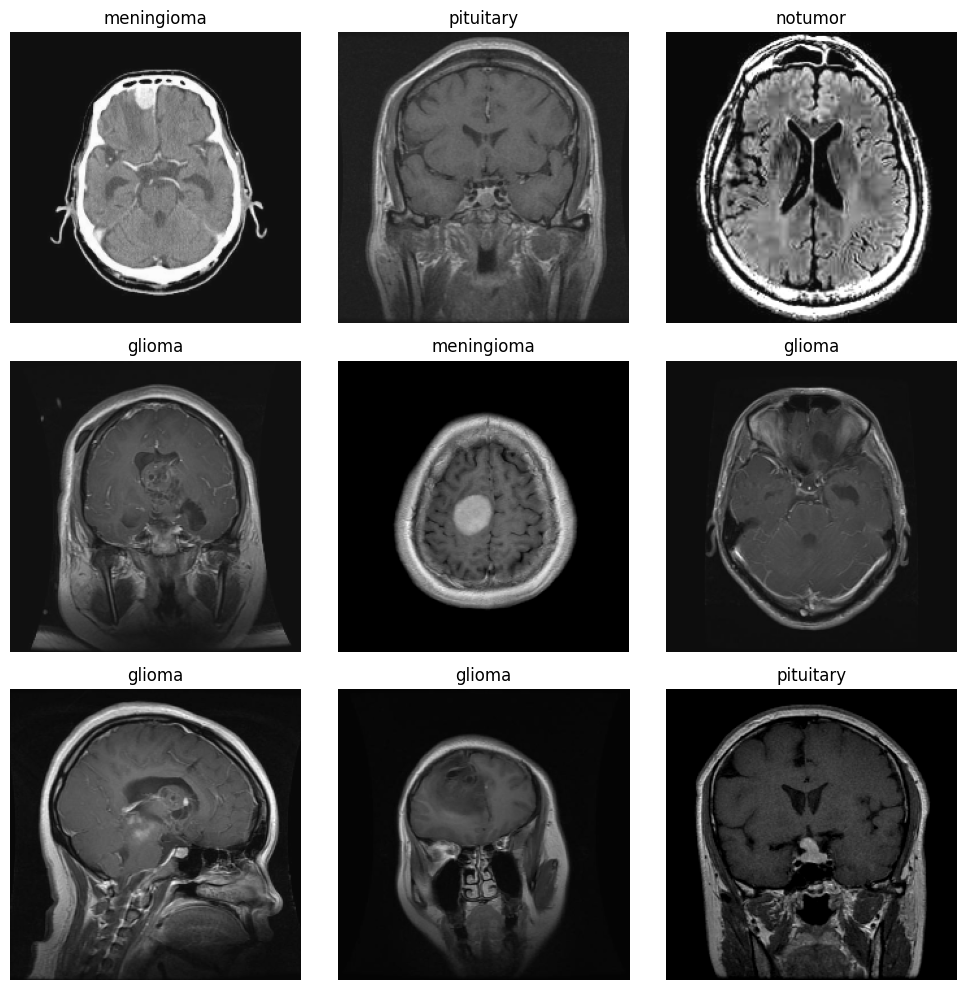

In [4]:
# Grab a batch from the dataset and plot it
images, labels = next(iter(train_ds.take(1)))

# 2. Plot a 3x3 grid
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(classes[labels[i]]) # Using the class list from earlier
    plt.axis("off")

plt.tight_layout()
plt.show()

### Define the model

In [5]:
# # Loading Pretrained ResNet50

import time
import tensorflow as tf
from tensorflow.keras import layers, models, Input

# 1. Setup Model (Functional API)
base_model = tf.keras.applications.ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False 

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(classes), activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)

# 2. Define Loss, Optimizer, and Metrics
loss_object = tf.keras.losses.SparseCategoricalCrossentropy()
optimizer = tf.keras.optimizers.Adam()

train_loss_metric = tf.keras.metrics.Mean(name='train_loss')
train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')
val_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy(name='val_accuracy')

## Training loops
@tf.function(jit_compile=True)
def train_step(images, labels):
    with tf.GradientTape() as tape:
        # Forward pass
        predictions = model(images, training=True)
        loss = loss_object(labels, predictions)    
    # Backpropagation step
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))    
    # Update metrics
    train_loss_metric.update_state(loss)
    train_acc_metric.update_state(labels, predictions)

@tf.function(jit_compile=True)
def val_step(images, labels):
    predictions = model(images, training=False)
    val_acc_metric.update_state(labels, predictions)

epochs = 40
start_time = time.time()

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    # Reset metrics at start of each epoch
    train_loss_metric.reset_state()
    train_acc_metric.reset_state()
    val_acc_metric.reset_state()
    # Training loop
    for step, (images, labels) in enumerate(train_ds):
        train_step(images, labels)
    # Validation loop
    for images, labels in val_ds:
        val_step(images, labels)
    print(f"Final -> Train Acc: {train_acc_metric.result():.4f} | Val Acc: {val_acc_metric.result():.4f}")

print(f"\nTotal Training Time: {time.time() - start_time:.2f} seconds")



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Epoch 1/40


I0000 00:00:1776167586.620807      55 service.cc:152] XLA service 0x1eafb920 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776167586.620841      55 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776167586.620844      55 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776167588.277902      55 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776167596.151338      55 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Final -> Train Acc: 0.4339 | Val Acc: 0.4339

Epoch 2/40
Final -> Train Acc: 0.5683 | Val Acc: 0.5241

Epoch 3/40
Final -> Train Acc: 0.6022 | Val Acc: 0.6187

Epoch 4/40
Final -> Train Acc: 0.6391 | Val Acc: 0.6625

Epoch 5/40
Final -> Train Acc: 0.6540 | Val Acc: 0.6696

Epoch 6/40
Final -> Train Acc: 0.6705 | Val Acc: 0.6696

Epoch 7/40
Final -> Train Acc: 0.6741 | Val Acc: 0.6821

Epoch 8/40
Final -> Train Acc: 0.6848 | Val Acc: 0.6839

Epoch 9/40
Final -> Train Acc: 0.6904 | Val Acc: 0.6938

Epoch 10/40
Final -> Train Acc: 0.6891 | Val Acc: 0.6991

Epoch 11/40
Final -> Train Acc: 0.6991 | Val Acc: 0.6982

Epoch 12/40
Final -> Train Acc: 0.7125 | Val Acc: 0.7045

Epoch 13/40
Final -> Train Acc: 0.7150 | Val Acc: 0.7080

Epoch 14/40
Final -> Train Acc: 0.7127 | Val Acc: 0.7205

Epoch 15/40
Final -> Train Acc: 0.7138 | Val Acc: 0.7179

Epoch 16/40
Final -> Train Acc: 0.7230 | Val Acc: 0.7000

Epoch 17/40
Final -> Train Acc: 0.7201 | Val Acc: 0.7232

Epoch 18/40
Final -> Train Acc: 0.